In [64]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [65]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps
from scipy.ndimage import binary_dilation

In [66]:
def z_interp(h, field_vals_all, lon, lat, z_val):
    field_vals = np.zeros((len(lat), len(lon)))
    for i in np.arange(len(lat)):
        for j in np.arange(len(lon)):
            if h[-1,i,j] > z_val:
                # This value is inside the topography
                field_vals[i,j] = np.nan
            else:
                # Find indices either side of this value
                low_idx = np.where(h[:,i,j] < z_val)[0][0]
                high_idx = np.where(h[:,i,j] > z_val)[0][-1]

                # Compute weightings
                weight_low = (z_val - h[low_idx,i,j])/(h[high_idx,i,j] - h[low_idx,i,j])
                weight_high = 1. - weight_low

                # Compute and store value
                field_vals[i,j] = weight_low*field_vals_all[low_idx, i, j] + weight_high*field_vals_all[high_idx, i, j]
    return field_vals

def cubic_z_interp(h, field_vals_all, lon, lat, z_val):
    # Now make cubic interpolation coefficients for each grid staggering

    # Use the bottom four levels (in Python notation!)
    levels = [-1, -2, -3, -4]
    
    coeffs = np.zeros((4, len(lat), len(lon)))

    # Compute weights using interpolating polynomials
    coeffs[0] = (
        (z_val - h[levels[1]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[0]] - h[levels[1]]) * (h[levels[0]] - h[levels[2]])
        * (h[levels[0]] - h[levels[3]])
    )
    coeffs[1] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[2]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[1]] - h[levels[0]]) * (h[levels[1]] - h[levels[2]])
        * (h[levels[1]] - h[levels[3]])
    )
    coeffs[2] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[3]])
    ) / (
        (h[levels[2]] - h[levels[0]]) * (h[levels[2]] - h[levels[1]])
        * (h[levels[2]] - h[levels[3]])
    )
    coeffs[3] = (
        (z_val - h[levels[0]]) * (z_val - h[levels[1]])
        * (z_val - h[levels[2]])
    ) / (
        (h[levels[3]] - h[levels[0]]) * (h[levels[3]] - h[levels[1]])
        * (h[levels[3]] - h[levels[2]])
    )

    field_vals = np.zeros((len(lat), len(lon)))
    
    for i in np.arange(4):
        field_vals += coeffs[i]*field_vals_all[levels[i]]

    # Set values below surface to NaN
    field_vals = np.where(
        h[levels[0]] > z_val, np.nan, field_vals
    )
    
    return field_vals

In [67]:
savefig=True

rot = True

# Choose the dynamical core
#model = 'se'
#model = 'fv3'
model = 'mpas'

if model == 'se':
    dycore = 'CAM-SE'
    res = 'se_ne60'
    test_name_start = 'cam_6_4_100'
    lev_no = 'ztop20km_L57_new_RF'
    file_end = '.nc'
    
    extra_name1 = 'tau_100s'
    extra_name2 = 'tau_100s_diff_2x_weaker'
elif model == 'fv3':
    dycore = 'CAM-FV3'
    res = 'fv3_C192'
    test_name_start = 'cam_6_4_070_horiz_mount_flow'
    lev_no = 'ztop20km_L57_new_RF'
    file_end = '.regrid.0.5x0.5.nc'
    
    extra_name1 = 'tau100s'
    extra_name2 = 'tau100s_hord5'  
elif model == 'mpas':
    dycore = 'CAM-MPAS'
    res = 'mpasa60'
    test_name_start = 'cam_6_4_080_paper_six'
    lev_no = 'L20km_L57_new_RF_w0'
    file_end = '.regrid.0.5x0.5.nc'
    
    extra_name1 = 'tau100s'
    extra_name2 = 'tau100s_divfact_1' 

case = f'{test_name_start}_{res}_{lev_no}'

# Compare three files
if rot:
    nc_file1 = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name1}{file_end}'
    nc_file2 = f'{case}.cam.h0i.0001-01-01-00000_gap_with_rot_{extra_name2}{file_end}'
else:
    nc_file1 = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name1}{file_end}'
    nc_file2 = f'{case}.cam.h0i.0001-01-01-00000_gap_omega0_{extra_name2}{file_end}'


In [68]:
run_base = "/glade/derecho/scratch/timand/"

run_path1 = run_base + case + '/run/' + nc_file1
run_path2 = run_base + case + '/run/' + nc_file2

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)

In [69]:
time = nc1['time'][:]
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 

print(np.size(lat), np.size(lon))

361 720


In [70]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat

# Consistent lon lat ranges
lat_crop_up = 50.
lat_cent_down = -50.
lat_ticks = np.linspace(-40.,40.,5)

lon_crop_left = 140.
lon_crop_right = 280.
#lon_ticks = np.linspace(140, 280, 8)
lon_ticks = np.array([140,180,220,260])

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

lon_lfric = lon_inds - 180

print(np.shape(lon_crop))

(281,)


In [71]:
# Time index to compare at
t_idx = 40

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [72]:
# Interpolations of U and T

U_field_vals1 = cubic_z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
U_field_vals2 = cubic_z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['U'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

T_field_vals1 = cubic_z_interp(nc1['Z3'][t_idx, :, lat_inds, lon_inds], nc1['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)
T_field_vals2 = cubic_z_interp(nc2['Z3'][t_idx, :, lat_inds, lon_inds], nc2['T'][t_idx, :, lat_inds, lon_inds], lon_crop, lat_crop, z_val)

In [73]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1 = (U_field_vals1 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2 = (U_field_vals2 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

# Temperature perturbation:
T_field_vals1 = T_field_vals1 - T0
T_field_vals2 = T_field_vals2 - T0

In [74]:
# What are the maximum values AWAY from the mountain??
lon_max_inds = np.where(np.logical_or((lon_crop <= 170),(lon_crop >= 190)))[0]

U_max_crop1 = U_field_vals1[:,lon_max_inds]
T_max_crop1 = T_field_vals1[:,lon_max_inds]

U_max_crop2 = U_field_vals2[:,lon_max_inds]
T_max_crop2 = T_field_vals2[:,lon_max_inds]


In [75]:
# New method --- compute everywhere away from the orography.
# Mask the orography values to zero.
def exclude_mountain_neighbourhood(*fields, iterations=1):
    """
    Return copies of fields with the mountain and `iterations`
    surrounding grid cells masked as NaN.
    """
    fields = [
        np.ma.filled(np.ma.asarray(field, dtype=float), np.nan)
        for field in fields
    ]

    # Exclude any point masked as mountain in any model.
    mountain = np.logical_or.reduce([~np.isfinite(field) for field in fields])

    # Add one grid cell in every direction, including diagonals.
    exclude = binary_dilation(
        mountain,
        structure=np.ones((3, 3), dtype=bool),
        iterations=iterations
    )

    return [np.where(exclude, np.nan, field) for field in fields]

(
    T_stats1,
    T_stats2,
) = exclude_mountain_neighbourhood(
    T_field_vals1,
    T_field_vals2,
    iterations=1
)

(
    U_stats1,
    U_stats2,
) = exclude_mountain_neighbourhood(
    U_field_vals1,
    U_field_vals2,
    iterations=1
)

T_min1, T_max1 = np.nanmin(T_stats1), np.nanmax(T_stats1)
T_min2, T_max2 = np.nanmin(T_stats2), np.nanmax(T_stats2)

U_min1, U_max1 = np.nanmin(U_stats1), np.nanmax(U_stats1)
U_min2, U_max2 = np.nanmin(U_stats2), np.nanmax(U_stats2)

print(T_min1, T_max1)
print(f'a T min {np.min(T_max_crop1):.2f}, T max {np.max(T_max_crop1):.2f} \n')

print(T_min2, T_max2)
print(f'b T min {np.min(T_max_crop2):.2f}, T max {np.max(T_max_crop2):.2f} \n')


print(U_min1, U_max1)
print(f'a U min {np.min(U_max_crop1):.2f}, U max {np.max(U_max_crop1):.2f} \n')

print(U_min2, U_max2)
print(f'b U min {np.min(U_max_crop2):.2f}, U max {np.max(U_max_crop2):.2f} \n')

-2.5859012603759766 7.911500930786133
a T min -2.59, T max 7.91 

-2.6061001464420315 7.945470809936523
b T min -2.46, T max 7.95 

-2.5420437132381926 2.50829588703562
a U min -1.47, U max 1.48 

-1.800573255406699 2.540413012602635
b U min -1.40, U max 1.41 



min value is -2.5420437132381926
max value is 2.540413012602635


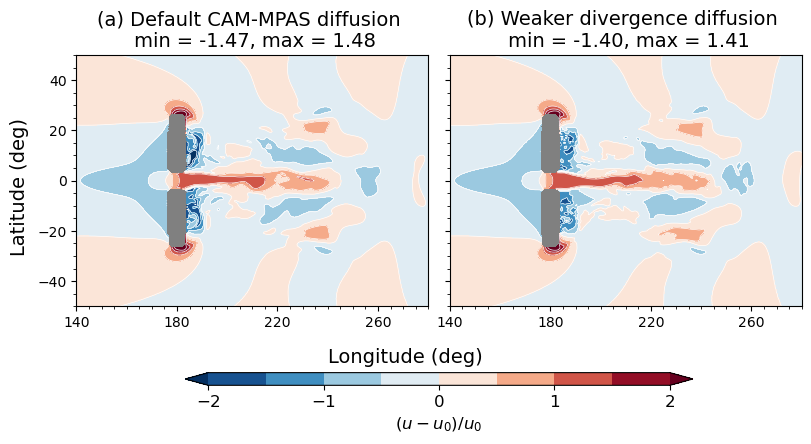

In [76]:
# Plot for U
U_cmap = matplotlib.cm.RdBu_r


U_maxmax = max(U_max1, U_max2)
U_minmin = min(U_min1, U_min2)

print('min value is', U_minmin)
print('max value is', U_maxmax)

if rot:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")
else:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,6.5), layout="constrained")
    
(ax1, ax2) = axes

# Consistent scales between with/without rotation
U_conts = np.linspace(-2.0, 2.0, 9)
tick_range = np.linspace(-2.0, 2.0, 5)
norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)


plot1 = ax1.contourf(LON, LAT, U_field_vals1, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
#plot4 = ax4.contourf(LON, LAT, U_field_vals4)
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
ax1.contour(LON, LAT, U_field_vals1, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, U_field_vals2, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

# Overall extrema
#ax1.set_title(f'{dycore1} \n min = {np.round(U_min1,2)}, max = {np.round(U_max1,2)}', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(U_min2,2)}, max = {np.round(U_max2,2)}', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(U_min3,2)}, max = {np.round(U_max3,2)}', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(U_min4,2)}, max = {np.round(U_max4,2)}', size=label_size)

# Extrema away from the mountain
if model == 'se':
    ax1.set_title(f'(a) Default CAM-SE diffusion \n min = {np.min(U_max_crop1):.2f}, max = {np.max(U_max_crop1):.2f}', size=label_size)
    ax2.set_title(f'(b) Half-strength diffusion \n min = {np.min(U_max_crop2):.2f}, max = {np.max(U_max_crop2):.2f}', size=label_size)
elif model == 'fv3':
    ax1.set_title(f'(a) Default CAM-FV3 transport \n min = {np.min(U_max_crop1):.2f}, max = {np.max(U_max_crop1):.2f}', size=label_size)
    ax2.set_title(f'(b) Virtually inviscid transport \n min = {np.min(U_max_crop2):.2f}, max = {np.max(U_max_crop2):.2f}', size=label_size)
elif model == 'mpas':
    ax1.set_title(f'(a) Default CAM-MPAS diffusion \n min = {np.min(U_max_crop1):.2f}, max = {np.max(U_max_crop1):.2f}', size=label_size)
    ax2.set_title(f'(b) Weaker divergence diffusion \n min = {np.min(U_max_crop2):.2f}, max = {np.max(U_max_crop2):.2f}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.14)

if savefig:
    if rot:
        plt.savefig(f'figures/gap_{model}_diffusion_with_rot_U.png', bbox_inches='tight')
    else:
        plt.savefig(f'figures/gap_{model}_diffusion_omega0_U.png', bbox_inches='tight')


7.911500930786133


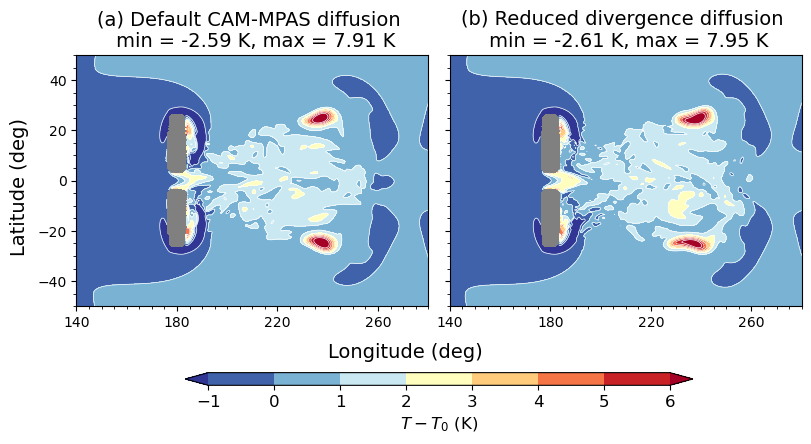

In [77]:
### T plot
fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")

(ax1, ax2) = axes

T_cmap = copy.copy(matplotlib.cm.RdYlBu_r)
T_conts = np.linspace(-1, 6, 8)
norm = colors.Normalize(vmin=-1, vmax=6)

tick_range = np.linspace(-1, 6, 8)
    
plot1 = ax1.contourf(LON, LAT, T_field_vals1, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, T_field_vals2, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')

# If we want contours overlaid:
ax1.contour(LON, LAT, T_field_vals1, levels = T_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, T_field_vals2, levels = T_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')

T_title = 'Temperature perturbation'
for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label='$T - T_0$ (K)', size=small_size)
cb.ax.tick_params(labelsize=12)

# Extrema over the full domain
#ax1.set_title(f'{dycore1} \n min = {np.round(T_min1,2)} K, max = {np.round(T_max1,2)} K', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(T_min2,2)} K, max = {np.round(T_max2,2)} K', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(T_min3,2)} K, max = {np.round(T_max3,2)} K', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(T_min4,2):.2f} K, max = {np.round(T_max4,2):.2f} K', size=label_size)

# Extrema away from the mountain
if model == 'se':
    ax1.set_title(f'(a) Default CAM-SE diffusion \n min = {np.min(T_max_crop1):.2f} K, max = {np.max(T_max_crop1):.2f} K', size=label_size)
    ax2.set_title(f'(b) Half-strength diffusion \n min = {np.min(T_max_crop2):.2f} K, max = {np.max(T_max_crop2):.2f} K', size=label_size)
elif model == 'fv3':
    ax1.set_title(f'(a) Default CAM-FV3 transport \n min = {T_min1:.2f} K, max = {T_max1:.2f} K', size=label_size)
    ax2.set_title(f'(b) Virtually inviscid transport \n min = {T_min2:.2f} K, max = {T_max2:.2f} K', size=label_size)
elif model == 'mpas':
    ax1.set_title(f'(a) Default CAM-MPAS diffusion \n min = {T_min1:.2f} K, max = {T_max1:.2f} K', size=label_size)
    ax2.set_title(f'(b) Reduced divergence diffusion \n min = {T_min2:.2f} K, max = {T_max2:.2f} K', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.15)

if savefig:
    if rot:
        plt.savefig(f'figures/gap_{model}_diffusion_with_rot_T.png', dpi=500, bbox_inches='tight')
    else:
        plt.savefig(f'figures/gap_{model}_diffusion_omega0_T.png', bbox_inches='tight')

print(T_max1)


In [78]:
# Examine the effect on asymmetry


T_asym1=0
T_asym2=0

eq_ind = 100
new_lon_inds = np.where((lon_crop <= 260) & (lon_crop >= 220))[0]


for i in np.arange(100):
    T_asym1 += np.nansum(np.abs(T_field_vals1[eq_ind+i, :] - T_field_vals1[eq_ind-i, :]))
    T_asym2 += np.nansum(np.abs(T_field_vals2[eq_ind+i, :] - T_field_vals2[eq_ind-i, :]))

T_asym1 /= (100*281)
T_asym2 /= (100*281)

print(T_asym1)
print(T_asym2)

0.08186015342136382
0.12526948584344144


In [79]:
# Examine the impact on the locaiton of max T' in each hemisphere.
def find_hemisphere_max(field_vals, lon, lat, hemisphere,
                        lon_bounds=None):
    """
    Find the maximum field value in one hemisphere.

    Parameters
    ----------
    field_vals : 2-D array, shape (nlat, nlon)
        Temperature perturbation field.
    lon, lat : 1-D or 2-D arrays
        Longitude and latitude coordinates.
    hemisphere : {"north", "south"}
        Hemisphere in which to search.
    lon_bounds : tuple or None
        Optional (minimum_longitude, maximum_longitude) search range.
        For example, (190, 270) restricts the search to the lee region.

    Returns
    -------
    result : dict
        Maximum value, longitude, latitude, and array indices.
    """

    # Convert masked values to NaN
    field_vals = np.ma.filled(
        np.ma.asarray(field_vals, dtype=float), np.nan
    )

    # Construct 2-D coordinate arrays if lon and lat are 1-D
    if np.ndim(lon) == 1 and np.ndim(lat) == 1:
        LON, LAT = np.meshgrid(lon, lat)
    else:
        LON = np.asarray(lon)
        LAT = np.asarray(lat)

    if field_vals.shape != LON.shape or field_vals.shape != LAT.shape:
        raise ValueError(
            f"Incompatible shapes: field={field_vals.shape}, "
            f"LON={LON.shape}, LAT={LAT.shape}"
        )

    hemisphere = hemisphere.lower()

    if hemisphere in ("north", "northern", "nh"):
        search_mask = LAT > 0
    elif hemisphere in ("south", "southern", "sh"):
        search_mask = LAT < 0
    else:
        raise ValueError("hemisphere must be 'north' or 'south'")

    # Optionally restrict the search to the downstream/lee region
    if lon_bounds is not None:
        lon_min, lon_max = lon_bounds

        if lon_min <= lon_max:
            search_mask &= (LON >= lon_min) & (LON <= lon_max)
        else:
            # Supports a longitude interval crossing 0 degrees
            search_mask &= (LON >= lon_min) | (LON <= lon_max)

    search_mask &= np.isfinite(field_vals)

    if not np.any(search_mask):
        raise ValueError("No finite field values found in the search region.")

    # Points outside the selected region cannot be chosen
    search_field = np.where(search_mask, field_vals, np.nan)

    row, col = np.unravel_index(
        np.nanargmax(search_field),
        search_field.shape
    )

    return {
        "value": field_vals[row, col],
        "lon": LON[row, col],
        "lat": LAT[row, col],
        "row": row,
        "col": col,
    }



In [80]:
# Restrict the search to the lee side so that maxima near the
# topography are not accidentally identified as vortex centers.
# Use lon_bounds=None if you want to search the entire plotted domain.
lee_lon_bounds = (190, 270)

results = {
    "(a) def north": find_hemisphere_max(
        T_field_vals1, lon_crop, lat_crop, "north", lee_lon_bounds
    ),
    "(a) def south": find_hemisphere_max(
        T_field_vals1, lon_crop, lat_crop, "south", lee_lon_bounds
    ),
    "(b) less diff north": find_hemisphere_max(
        T_field_vals2, lon_crop, lat_crop, "north", lee_lon_bounds
    ),
    "(b) less diff south": find_hemisphere_max(
        T_field_vals2, lon_crop, lat_crop, "south", lee_lon_bounds
    ),
}

for name, result in results.items():
    print(
        f"{name:12s}: "
        f"max T' = {result['value']:.3f} K, "
        f"lon = {result['lon']:.3f} deg, "
        f"lat = {result['lat']:.3f} deg, "
        f"index = ({result['row']}, {result['col']})"
    )

(a) def north: max T' = 7.912 K, lon = 237.500 deg, lat = 25.000 deg, index = (150, 195)
(a) def south: max T' = 7.859 K, lon = 238.000 deg, lat = -25.000 deg, index = (50, 196)
(b) less diff north: max T' = 7.945 K, lon = 239.000 deg, lat = 24.500 deg, index = (149, 198)
(b) less diff south: max T' = 7.583 K, lon = 237.500 deg, lat = -25.000 deg, index = (50, 195)


In [81]:
print(len(lon_crop))

281
